## Data Collection

In [1]:
!pip install requests beautifulsoup4 pandas lxml

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

In [3]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
}

In [4]:
url = "https://www.naukri.com/data-scientist-jobs"

response = requests.get(url, headers=headers)
print("Status Code:", response.status_code)
print(response.text[:1000])

Status Code: 200
<!DOCTYPE html><html lang="en"><head><meta charSet="utf-8"/><link rel="dns-prefetch" href="https://www.googletagmanager.com"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/69d8d7e3e2ff0cb7.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/53ad1923b447bc22.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/78d41feaba858687.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/7d9a0cf29dbbd70f.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/b09725aaa4a54f31.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/ddb0e4dfe6602a68.css" data-precedence="next"/><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/8261187dc13c11

In [5]:
#reads the html,formats it nicely,shows the first page of the page source
soup = BeautifulSoup(response.text, "lxml")
print(soup.prettify()[:3000])

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <link href="https://www.googletagmanager.com" rel="dns-prefetch"/>
  <link data-precedence="next" href="https://static.naukimg.com/s/9/121/_next/static/css/69d8d7e3e2ff0cb7.css" rel="stylesheet"/>
  <link data-precedence="next" href="https://static.naukimg.com/s/9/121/_next/static/css/53ad1923b447bc22.css" rel="stylesheet"/>
  <link data-precedence="next" href="https://static.naukimg.com/s/9/121/_next/static/css/78d41feaba858687.css" rel="stylesheet"/>
  <link data-precedence="next" href="https://static.naukimg.com/s/9/121/_next/static/css/7d9a0cf29dbbd70f.css" rel="stylesheet"/>
  <link data-precedence="next" href="https://static.naukimg.com/s/9/121/_next/static/css/b09725aaa4a54f31.css" rel="stylesheet"/>
  <link data-precedence="next" href="https://static.naukimg.com/s/9/121/_next/static/css/ddb0e4dfe6602a68.css" rel="stylesheet"/>
  <link data-precedence="next" href="https://static.naukimg.com/s/9/121/_next/static

In [6]:
job_cards = soup.find_all("article")

print("Total job cards found:", len(job_cards))

Total job cards found: 0


In [7]:
if len(job_cards) > 0:
    print(job_cards[0].prettify()[:5000])
else:
    print("No job cards found")

No job cards found


In [8]:
scripts = soup.find_all("script")

print("Total script tags:", len(scripts))

Total script tags: 7


In [9]:
for i, script in enumerate(scripts[:20]):
    if script.string:
        text = script.string.lower()
        if "job" in text or "title" in text or "company" in text:
            print(f"\n--- Script {i} ---\n")
            print(script.string[:3000])
#original data is hidden in this manual scrapping so we go to selenium


--- Script 2 ---


                        {
                            "prefetch": [{
                                "source": "document",
                                "expects_no_vary_search": "params=(\"src\")",
                                "where": {
                                    "and": [
                                        { "selector_matches": ".nI-gNb-Jobs a" }
                                    ]
                                },
                                "eagerness": "moderate"
                                }]
                        
                    }
                    


In [10]:
!pip install selenium webdriver-manager

In [11]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time

In [12]:
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

driver.get("https://www.naukri.com/data-scientist-jobs")
time.sleep(5)

In [13]:
job_cards = driver.find_elements(By.CSS_SELECTOR, "article")

print("Jobs found:", len(job_cards))

Jobs found: 0


In [14]:
if job_cards:
    print(job_cards[0].text)
else:
    print("No jobs found")

No jobs found


In [15]:
print(driver.title)

Data Scientist Jobs - 13337 Data Scientist Job Vacancies In April 2026 - Naukri.com


In [16]:
#where selenium actually loads the page
page_source = driver.page_source
print("Length of page source:", len(page_source))
print(page_source[:2000])

Length of page source: 373775
<html lang="en"><head><meta charset="utf-8"><link rel="dns-prefetch" href="https://www.googletagmanager.com"><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/69d8d7e3e2ff0cb7.css" data-precedence="next"><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/53ad1923b447bc22.css" data-precedence="next"><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/78d41feaba858687.css" data-precedence="next"><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/7d9a0cf29dbbd70f.css" data-precedence="next"><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/b09725aaa4a54f31.css" data-precedence="next"><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/ddb0e4dfe6602a68.css" data-precedence="next"><link rel="stylesheet" href="https://static.naukimg.com/s/9/121/_next/static/css/8261187dc13c11af.css" da

In [17]:
elements = driver.find_elements(By.XPATH, "//*")
print("Total elements loaded:", len(elements))

Total elements loaded: 2783


In [18]:
selectors = [
    "article",
    "div.cust-job-tuple",
    "div.srp-jobtuple-wrapper",
    "div.row1",
    "div.styles_jlc__main__VdwtF"
]

for sel in selectors:
    try:
        found = driver.find_elements(By.CSS_SELECTOR, sel)
        print(f"{sel} --> {len(found)}")
    except Exception as e:
        print(f"{sel} --> ERROR: {e}")

article --> 0
div.cust-job-tuple --> 25
div.srp-jobtuple-wrapper --> 20
div.row1 --> 25
div.styles_jlc__main__VdwtF --> 1


In [19]:
job_cards = driver.find_elements(By.CSS_SELECTOR, "div.cust-job-tuple")

print("Jobs found:", len(job_cards))

if job_cards:
    print(job_cards[0].text)
else:
    print("Still no jobs found")

Jobs found: 25
Data Scientist
ABB
4.0
3383 Reviews
2-7 Yrs
Bengaluru
MBA or Bachelors / masters degree in a quantitative discipline, such as mathematics, st...
data scientisttime series analysisstorytellingpythonaipower bibusiness analysishuman resources
1 day ago
Save


In [20]:
#job data extraction from current page
job_cards = driver.find_elements(By.CSS_SELECTOR, "div.cust-job-tuple")

jobs_data = []

for card in job_cards:
    try:
        # Job Title
        try:
            job_title = card.find_element(By.CSS_SELECTOR, "a.title").text
        except:
            job_title = None

        # Job Link
        try:
            job_link = card.find_element(By.CSS_SELECTOR, "a.title").get_attribute("href")
        except:
            job_link = None

        # Company Name
        try:
            company_name = card.find_element(By.CSS_SELECTOR, "a.comp-name").text
        except:
            company_name = None

        # Experience
        try:
            experience = card.find_element(By.CSS_SELECTOR, "span.expwdth").text
        except:
            experience = None

        # Location
        try:
            location = card.find_element(By.CSS_SELECTOR, "span.locWdth").text
        except:
            location = None

        # Skills
        try:
            skills_elements = card.find_elements(By.CSS_SELECTOR, "ul.tags-gt li")
            skills = ", ".join([skill.text for skill in skills_elements if skill.text.strip() != ""])
        except:
            skills = None

        # Posted Date
        try:
            posted_date = card.find_element(By.CSS_SELECTOR, "span.job-post-day").text
        except:
            posted_date = None

        jobs_data.append({
            "job_title": job_title,
            "company_name": company_name,
            "experience": experience,
            "location": location,
            "skills": skills,
            "posted_date": posted_date,
            "job_link": job_link
        })

    except Exception as e:
        print("Error extracting one card:", e)

print("Total extracted jobs:", len(jobs_data))
jobs_data[:3]

Total extracted jobs: 25


[{'job_title': 'Data Scientist',
  'company_name': 'ABB',
  'experience': '2-7 Yrs',
  'location': 'Bengaluru',
  'skills': 'data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources',
  'posted_date': '1 day ago',
  'job_link': 'https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284'},
 {'job_title': 'Data Scientist',
  'company_name': 'Cisco',
  'experience': '7-10 Yrs',
  'location': 'Bengaluru',
  'skills': 'Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics',
  'posted_date': '6 days ago',
  'job_link': 'https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991'},
 {'job_title': 'Head Artificial Intelligence',
  'company_name': None,
  'experience': None,
  'location': None,
  'skills': '',
  'posted_date': None,
  'job_link': None}]

In [21]:
df_jobs = pd.DataFrame(jobs_data)
df_jobs.head()

,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytel...",1 day ago,https://www.naukri.com/job-listings-data-scien...
1,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science,...",6 days ago,https://www.naukri.com/job-listings-data-scien...
2,Head Artificial Intelligence,None,None,None,,None,None
3,Data Scientist,None,None,None,,None,None
4,,None,None,None,,None,None


In [22]:
df_jobs.to_csv("naukri_jobs_page1.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!


In [23]:
# Remove rows where important fields are missing
df_jobs_clean = df_jobs.dropna(subset=["job_title", "company_name", "location"])

# Remove rows where job_title is too short or weird
df_jobs_clean = df_jobs_clean[df_jobs_clean["job_title"].str.len() > 3]

# Remove duplicate job links
df_jobs_clean = df_jobs_clean.drop_duplicates(subset=["job_link"])

# Reset index
df_jobs_clean = df_jobs_clean.reset_index(drop=True)

print("Original rows:", len(df_jobs))
print("Clean rows:", len(df_jobs_clean))

df_jobs_clean.head(10)

Original rows: 25
Clean rows: 19


,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytel...",1 day ago,https://www.naukri.com/job-listings-data-scien...
1,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science,...",6 days ago,https://www.naukri.com/job-listings-data-scien...
2,Data Scientist,Infosys,5-10 Yrs,"Hybrid - Hyderabad, Chennai, Bengaluru","NLP, Generative AI, Computer Vision, Computer,...",2 days ago,https://www.naukri.com/job-listings-data-scien...
3,Data Scientist,Mercedes Benz,3-6 Yrs,Bengaluru,"data scientist, kubernetes, python, scala, dat...",1 day ago,https://www.naukri.com/job-listings-data-scien...
4,Data Scientist,EY,7-10 Yrs,"Hybrid - Kochi, Bengaluru, Thiruvananthapuram","python, Machine Learning, sql, Statistical Mod...",1 week ago,https://www.naukri.com/job-listings-data-scien...
5,Data Scientist,Genpact,5-10 Yrs,"Hybrid - Hyderabad, Gurugram, Bengaluru","Artificial Intelligence, Machine Learning, Pyt...",1 day ago,https://www.naukri.com/job-listings-data-scien...
6,Data Scientist,EY,2-6 Yrs,"Delhi / NCR, Mumbai (All Areas)","LLM, Agentic Ai, Langgraph, Function Calling, ...",1 week ago,https://www.naukri.com/job-listings-data-scien...
7,Data Scientist,PayU,0-3 Yrs,Gurugram,"Usage, Statistical analysis, Analytical, Focus...",3 days ago,https://www.naukri.com/job-listings-data-scien...
8,Data Scientist,Gartner for HR,3-8 Yrs,Gurugram,"Computer science, Development Manager, Coding,...",1 day ago,https://www.naukri.com/job-listings-data-scien...
9,Data Scientist,EY,9-14 Yrs,Hyderabad,"Data Science, Machine Learning Algorithms, Pyt...",2 days ago,https://www.naukri.com/job-listings-data-scien...


In [24]:
df_jobs_clean.to_csv("naukri_jobs_page1_clean.csv", index=False)
print("Clean CSV saved successfully!")

Clean CSV saved successfully!


In [25]:
pd.set_option("display.max_colwidth", None)
df_jobs_clean[["job_title", "company_name", "job_link"]].head(5)

,job_title,company_name,job_link
0,Data Scientist,ABB,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
1,Data Scientist,Cisco,https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991
2,Data Scientist,Infosys,https://www.naukri.com/job-listings-data-scientist-infosys-hyderabad-chennai-bengaluru-5-to-10-years-300326019242
3,Data Scientist,Mercedes Benz,https://www.naukri.com/job-listings-data-scientist-mercedes-benz-research-and-development-india-pvt-ltd-bengaluru-3-to-6-years-020426925684
4,Data Scientist,EY,https://www.naukri.com/job-listings-data-scientist-ey-kochi-bengaluru-thiruvananthapuram-7-to-10-years-041225020462


In [26]:
search_roles = [
    "data-scientist-jobs",
    "data-analyst-jobs",
    "machine-learning-engineer-jobs",
    "artificial-intelligence-engineer-jobs"
]

search_role_names = {
    "data-scientist-jobs": "Data Scientist",
    "data-analyst-jobs": "Data Analyst",
    "machine-learning-engineer-jobs": "Machine Learning Engineer",
    "artificial-intelligence-engineer-jobs": "AI Engineer"
}

In [27]:
all_jobs = []

for role_slug in search_roles:
    role_name = search_role_names[role_slug]
    url = f"https://www.naukri.com/{role_slug}"
    
    print(f"\nScraping: {role_name}")
    driver.get(url)
    time.sleep(5)

    job_cards = driver.find_elements(By.CSS_SELECTOR, "div.cust-job-tuple")
    print("Jobs found:", len(job_cards))

    for card in job_cards:
        try:
            # Job Title
            try:
                job_title = card.find_element(By.CSS_SELECTOR, "a.title").text
            except:
                job_title = None

            # Job Link
            try:
                job_link = card.find_element(By.CSS_SELECTOR, "a.title").get_attribute("href")
            except:
                job_link = None

            # Company Name
            try:
                company_name = card.find_element(By.CSS_SELECTOR, "a.comp-name").text
            except:
                company_name = None

            # Experience
            try:
                experience = card.find_element(By.CSS_SELECTOR, "span.expwdth").text
            except:
                experience = None

            # Location
            try:
                location = card.find_element(By.CSS_SELECTOR, "span.locWdth").text
            except:
                location = None

            # Skills
            try:
                skills_elements = card.find_elements(By.CSS_SELECTOR, "ul.tags-gt li")
                skills = ", ".join([skill.text for skill in skills_elements if skill.text.strip() != ""])
            except:
                skills = None

            # Posted Date
            try:
                posted_date = card.find_element(By.CSS_SELECTOR, "span.job-post-day").text
            except:
                posted_date = None

            all_jobs.append({
                "search_role": role_name,
                "job_title": job_title,
                "company_name": company_name,
                "experience": experience,
                "location": location,
                "skills": skills,
                "posted_date": posted_date,
                "job_link": job_link
            })

        except Exception as e:
            print("Error extracting one card:", e)


Scraping: Data Scientist
Jobs found: 25

Scraping: Data Analyst
Jobs found: 20

Scraping: Machine Learning Engineer
Jobs found: 20

Scraping: AI Engineer
Jobs found: 20


In [28]:
df_all_jobs = pd.DataFrame(all_jobs)

print("Total rows before cleaning:", len(df_all_jobs))
df_all_jobs.head()

Total rows before cleaning: 85


,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources",1 day ago,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
1,Data Scientist,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics",6 days ago,https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991
2,Data Scientist,Sr. Artificial Intelligence Engineer,None,None,None,,None,None
3,Data Scientist,Power BI Analyst,None,None,None,,None,None
4,Data Scientist,,None,None,None,,None,None


In [29]:
df_all_jobs_clean = df_all_jobs.dropna(subset=["job_title", "company_name", "location"])
df_all_jobs_clean = df_all_jobs_clean[df_all_jobs_clean["job_title"].str.len() > 3]
df_all_jobs_clean = df_all_jobs_clean.drop_duplicates(subset=["job_link"])
df_all_jobs_clean = df_all_jobs_clean.reset_index(drop=True)

print("Total rows after cleaning:", len(df_all_jobs_clean))
df_all_jobs_clean.head(10)

Total rows after cleaning: 79


,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources",1 day ago,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
1,Data Scientist,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics",6 days ago,https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991
2,Data Scientist,Data Scientist,Infosys,5-10 Yrs,"Hybrid - Hyderabad, Chennai, Bengaluru","NLP, Generative AI, Computer Vision, Computer, Artificial Intelligence, Data, Vision, Natural language processing",2 days ago,https://www.naukri.com/job-listings-data-scientist-infosys-hyderabad-chennai-bengaluru-5-to-10-years-300326019242
3,Data Scientist,Data Scientist,Mercedes Benz,3-6 Yrs,Bengaluru,"data scientist, kubernetes, python, scala, data mining, aks, databricks, machine learning",1 day ago,https://www.naukri.com/job-listings-data-scientist-mercedes-benz-research-and-development-india-pvt-ltd-bengaluru-3-to-6-years-020426925684
4,Data Scientist,Data Scientist,EY,7-10 Yrs,"Hybrid - Kochi, Bengaluru, Thiruvananthapuram","python, Machine Learning, sql, Statistical Modeling, data scientist, Tensorflow, Azure, Generative Ai",1 week ago,https://www.naukri.com/job-listings-data-scientist-ey-kochi-bengaluru-thiruvananthapuram-7-to-10-years-041225020462
5,Data Scientist,Data Scientist,Genpact,5-10 Yrs,"Hybrid - Hyderabad, Gurugram, Bengaluru","Artificial Intelligence, Machine Learning, Python, Intelligence, Data, Machine",1 day ago,https://www.naukri.com/job-listings-data-scientist-genpact-hyderabad-gurugram-bengaluru-5-to-10-years-010426025403
6,Data Scientist,Data Scientist,EY,2-6 Yrs,"Delhi / NCR, Mumbai (All Areas)","LLM, Agentic Ai, Langgraph, Function Calling, AWS, Semantic Kernel, Langchain, AI Agents",1 week ago,https://www.naukri.com/job-listings-data-scientist-ey-delhi-ncr-mumbai-all-areas-2-to-6-years-260326000141
7,Data Scientist,Data Scientist,PayU,0-3 Yrs,Gurugram,"Usage, Statistical analysis, Analytical, Focus, Programming, Data mining, Business understanding, Analytics",3 days ago,https://www.naukri.com/job-listings-data-scientist-payu-india-gurugram-0-to-3-years-300326502718
8,Data Scientist,Data Scientist,Gartner for HR,3-8 Yrs,Gurugram,"Computer science, Development Manager, Coding, Analytical, Data collection, Workflow, Information retrieval, Medical insurance",1 day ago,https://www.naukri.com/job-listings-data-scientist-gartner-for-hr-gurugram-3-to-8-years-010426504849
9,Data Scientist,Data Scientist,EY,9-14 Yrs,Hyderabad,"Data Science, Machine Learning Algorithms, Python, Pytorch, Data Quality, DevOps, Data Modeling, Data Architecture",2 days ago,https://www.naukri.com/job-listings-data-scientist-ey-hyderabad-9-to-14-years-310326033769


In [30]:
df_all_jobs_clean.to_csv("naukri_jobs_dataset.csv", index=False)
print("Main dataset saved successfully!")

Main dataset saved successfully!


## EDA 

In [31]:
import pandas as pd

df = pd.read_csv("naukri_jobs_dataset.csv")
df.head()

,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources",1 day ago,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
1,Data Scientist,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics",6 days ago,https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991
2,Data Scientist,Data Scientist,Infosys,5-10 Yrs,"Hybrid - Hyderabad, Chennai, Bengaluru","NLP, Generative AI, Computer Vision, Computer, Artificial Intelligence, Data, Vision, Natural language processing",2 days ago,https://www.naukri.com/job-listings-data-scientist-infosys-hyderabad-chennai-bengaluru-5-to-10-years-300326019242
3,Data Scientist,Data Scientist,Mercedes Benz,3-6 Yrs,Bengaluru,"data scientist, kubernetes, python, scala, data mining, aks, databricks, machine learning",1 day ago,https://www.naukri.com/job-listings-data-scientist-mercedes-benz-research-and-development-india-pvt-ltd-bengaluru-3-to-6-years-020426925684
4,Data Scientist,Data Scientist,EY,7-10 Yrs,"Hybrid - Kochi, Bengaluru, Thiruvananthapuram","python, Machine Learning, sql, Statistical Modeling, data scientist, Tensorflow, Azure, Generative Ai",1 week ago,https://www.naukri.com/job-listings-data-scientist-ey-kochi-bengaluru-thiruvananthapuram-7-to-10-years-041225020462


In [32]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of dataset: (79, 8)

Columns:
Index(['search_role', 'job_title', 'company_name', 'experience', 'location',
       'skills', 'posted_date', 'job_link'],
      dtype='object')

Data Types:
search_role     object
job_title       object
company_name    object
experience      object
location        object
skills          object
posted_date     object
job_link        object
dtype: object


In [33]:
print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

search_role     0
job_title       0
company_name    0
experience      0
location        0
skills          0
posted_date     0
job_link        0
dtype: int64


In [34]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate job links:", df["job_link"].duplicated().sum())

Duplicate rows: 0
Duplicate job links: 0


In [35]:
df.describe(include="all")

,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
count,79,79,79,79,79,79,79,79
unique,4,18,53,34,37,78,9,79
top,Data Analyst,Data Analyst,Tata Consultancy Services,5-10 Yrs,Bengaluru,"Artificial Intelligence, Natural Language Processing, Machine Learning, Python, Machine, Processing, Languages, Process",1 week ago,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
freq,20,20,8,9,13,2,21,1


In [36]:
text_cols = ["search_role", "job_title", "company_name", "experience", "location", "skills", "posted_date"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df.head()

,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources",1 day ago,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
1,Data Scientist,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics",6 days ago,https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991
2,Data Scientist,Data Scientist,Infosys,5-10 Yrs,"Hybrid - Hyderabad, Chennai, Bengaluru","NLP, Generative AI, Computer Vision, Computer, Artificial Intelligence, Data, Vision, Natural language processing",2 days ago,https://www.naukri.com/job-listings-data-scientist-infosys-hyderabad-chennai-bengaluru-5-to-10-years-300326019242
3,Data Scientist,Data Scientist,Mercedes Benz,3-6 Yrs,Bengaluru,"data scientist, kubernetes, python, scala, data mining, aks, databricks, machine learning",1 day ago,https://www.naukri.com/job-listings-data-scientist-mercedes-benz-research-and-development-india-pvt-ltd-bengaluru-3-to-6-years-020426925684
4,Data Scientist,Data Scientist,EY,7-10 Yrs,"Hybrid - Kochi, Bengaluru, Thiruvananthapuram","python, Machine Learning, sql, Statistical Modeling, data scientist, Tensorflow, Azure, Generative Ai",1 week ago,https://www.naukri.com/job-listings-data-scientist-ey-kochi-bengaluru-thiruvananthapuram-7-to-10-years-041225020462


In [37]:
df.to_csv("naukri_jobs_dataset.csv", index=False)

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

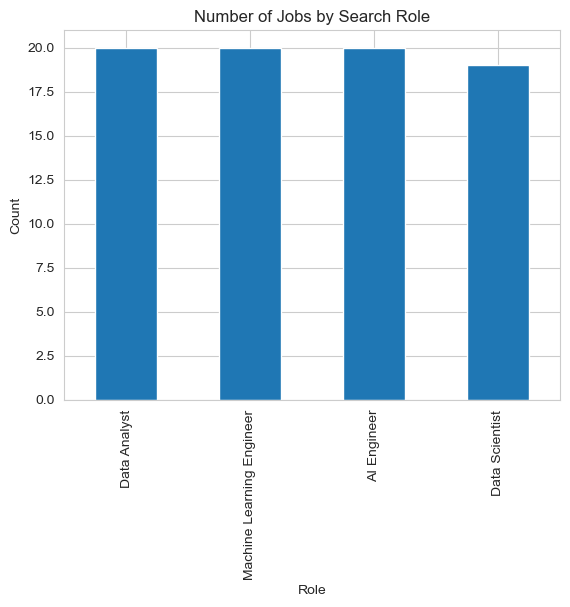

In [42]:
df["search_role"].value_counts().plot(kind="bar")
plt.title("Number of Jobs by Search Role")
plt.xlabel("Role")
plt.ylabel("Count")
plt.show()

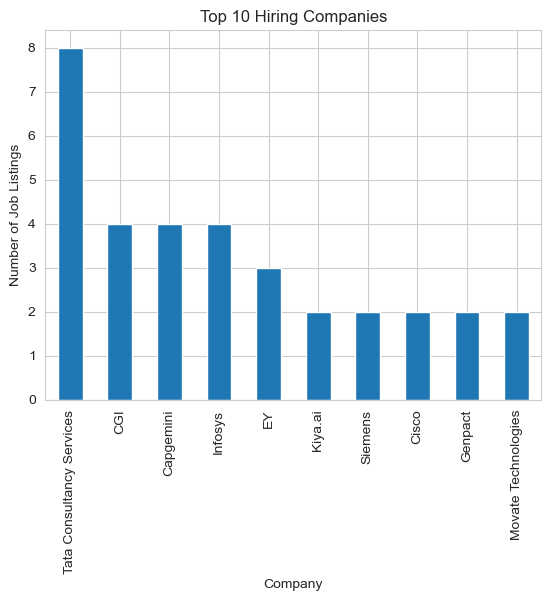

In [41]:
top_companies = df["company_name"].value_counts().head(10)

top_companies.plot(kind="bar")
plt.title("Top 10 Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Number of Job Listings")
# plt.xticks(rotation=)
plt.show()

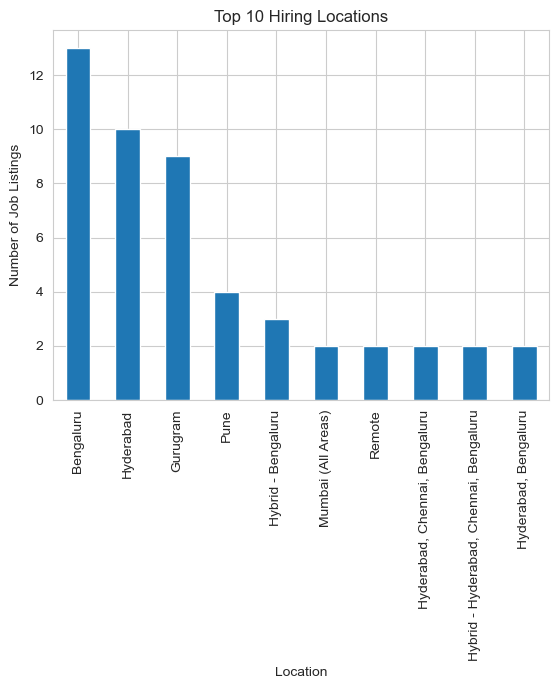

In [44]:
top_locations = df["location"].value_counts().head(10)

top_locations.plot(kind="bar")
plt.title("Top 10 Hiring Locations")
plt.xlabel("Location")
plt.ylabel("Number of Job Listings")
plt.show()

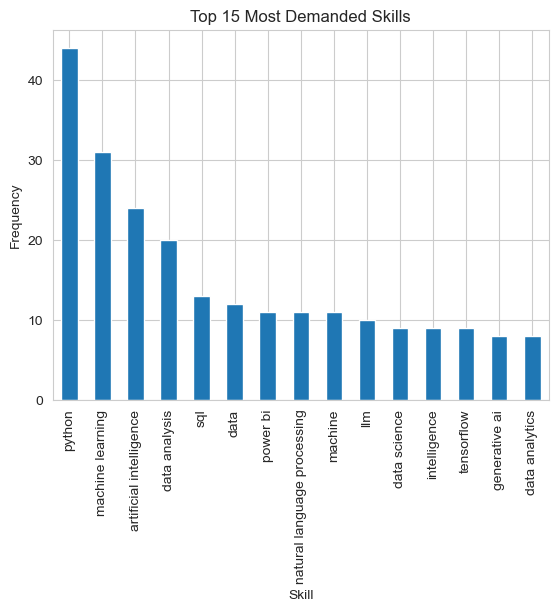

In [46]:
all_skills = df["skills"].dropna().str.lower().str.split(", ")
all_skills_flat = [skill for sublist in all_skills for skill in sublist if skill]

skills_series = pd.Series(all_skills_flat)
top_skills = skills_series.value_counts().head(15)

top_skills.plot(kind="bar")
plt.title("Top 15 Most Demanded Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.show()

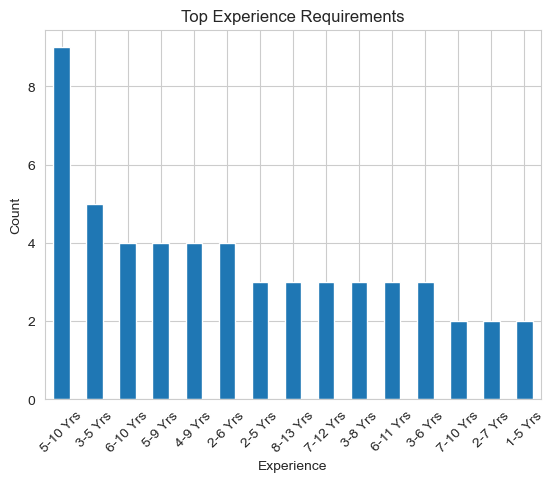

In [47]:
df["experience"].value_counts().head(15).plot(kind="bar")
plt.title("Top Experience Requirements")
plt.xlabel("Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [48]:
df_nlp = df.copy()
df_nlp.head()

,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources",1 day ago,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
1,Data Scientist,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics",6 days ago,https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991
2,Data Scientist,Data Scientist,Infosys,5-10 Yrs,"Hybrid - Hyderabad, Chennai, Bengaluru","NLP, Generative AI, Computer Vision, Computer, Artificial Intelligence, Data, Vision, Natural language processing",2 days ago,https://www.naukri.com/job-listings-data-scientist-infosys-hyderabad-chennai-bengaluru-5-to-10-years-300326019242
3,Data Scientist,Data Scientist,Mercedes Benz,3-6 Yrs,Bengaluru,"data scientist, kubernetes, python, scala, data mining, aks, databricks, machine learning",1 day ago,https://www.naukri.com/job-listings-data-scientist-mercedes-benz-research-and-development-india-pvt-ltd-bengaluru-3-to-6-years-020426925684
4,Data Scientist,Data Scientist,EY,7-10 Yrs,"Hybrid - Kochi, Bengaluru, Thiruvananthapuram","python, Machine Learning, sql, Statistical Modeling, data scientist, Tensorflow, Azure, Generative Ai",1 week ago,https://www.naukri.com/job-listings-data-scientist-ey-kochi-bengaluru-thiruvananthapuram-7-to-10-years-041225020462


In [49]:
df_nlp["skills"] = df_nlp["skills"].fillna("").str.lower().str.strip()
df_nlp["skills"].head()

0                         data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources
1    computer science, data analysis, data science, supply chain operations, data visualization, customer engagement, cisco, analytics
2                    nlp, generative ai, computer vision, computer, artificial intelligence, data, vision, natural language processing
3                                            data scientist, kubernetes, python, scala, data mining, aks, databricks, machine learning
4                                python, machine learning, sql, statistical modeling, data scientist, tensorflow, azure, generative ai
Name: skills, dtype: object

In [50]:
df_nlp["skills_list"] = df_nlp["skills"].apply(lambda x: [skill.strip() for skill in x.split(",") if skill.strip() != ""])
df_nlp[["job_title", "skills_list"]].head()

,job_title,skills_list
0,Data Scientist,"[data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources]"
1,Data Scientist,"[computer science, data analysis, data science, supply chain operations, data visualization, customer engagement, cisco, analytics]"
2,Data Scientist,"[nlp, generative ai, computer vision, computer, artificial intelligence, data, vision, natural language processing]"
3,Data Scientist,"[data scientist, kubernetes, python, scala, data mining, aks, databricks, machine learning]"
4,Data Scientist,"[python, machine learning, sql, statistical modeling, data scientist, tensorflow, azure, generative ai]"


In [51]:
#skill frequency table
all_skills = [skill for skills in df_nlp["skills_list"] for skill in skills]

skills_freq = pd.Series(all_skills).value_counts().reset_index()
skills_freq.columns = ["skill", "count"]

skills_freq.head(20)

,skill,count
0,python,44
1,machine learning,31
2,artificial intelligence,24
3,data analysis,20
4,sql,13
5,data,12
6,power bi,11
7,natural language processing,11
8,machine,11
9,llm,10


In [52]:
skills_freq.to_csv("top_skills_frequency.csv", index=False)
print("Top skills frequency file saved!")

Top skills frequency file saved!


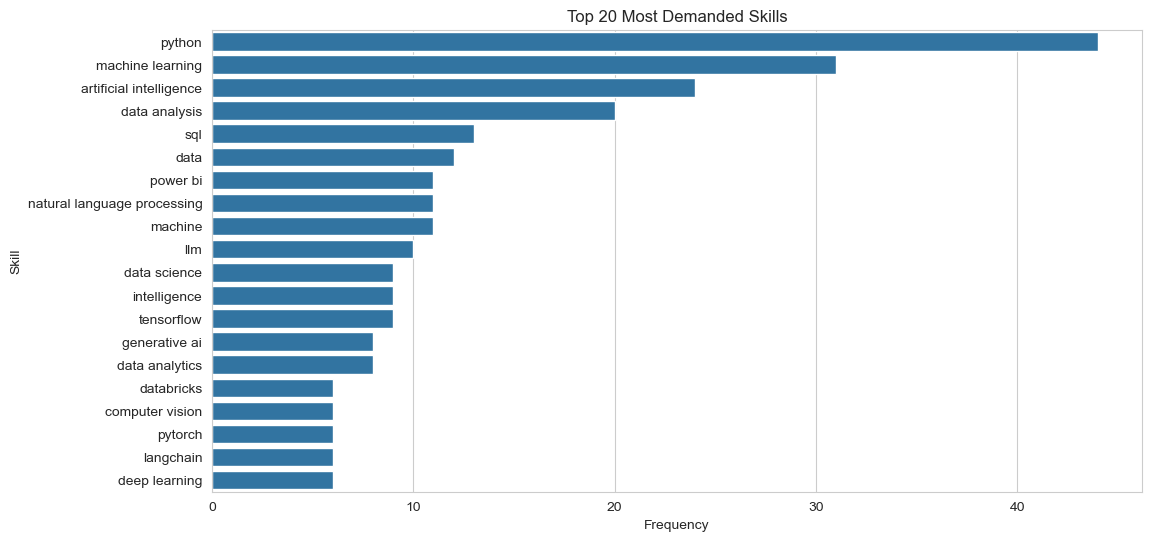

In [53]:
top20 = skills_freq.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=top20, x="count", y="skill")
plt.title("Top 20 Most Demanded Skills")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.show()

In [54]:
#which skill is most common in job roles
role_skill_data = []

for _, row in df_nlp.iterrows():
    for skill in row["skills_list"]:
        role_skill_data.append({
            "search_role": row["search_role"],
            "skill": skill
        })

role_skill_df = pd.DataFrame(role_skill_data)
role_skill_df.head()

,search_role,skill
0,Data Scientist,data scientist
1,Data Scientist,time series analysis
2,Data Scientist,storytelling
3,Data Scientist,python
4,Data Scientist,ai


In [55]:
#role specific skill demand
for role in role_skill_df["search_role"].unique():
    print(f"\nTop skills for {role}:")
    print(role_skill_df[role_skill_df["search_role"] == role]["skill"].value_counts().head(10))


Top skills for Data Scientist:
skill
python                     12
machine learning            7
data scientist              5
data                        4
data science                4
llm                         4
time series analysis        3
generative ai               3
databricks                  3
artificial intelligence     3
Name: count, dtype: int64

Top skills for Data Analyst:
skill
data analysis     16
power bi          10
python             9
sql                8
data analytics     7
data               7
bi                 5
data analyst       5
tableau            4
data quality       3
Name: count, dtype: int64

Top skills for Machine Learning Engineer:
skill
machine learning               16
python                         10
natural language processing     4
machine                         4
git                             3
sql                             3
artificial intelligence         3
tensorflow                      3
data science                    3
deep lear

In [56]:
role_skill_df.to_csv("role_wise_skills.csv", index=False)

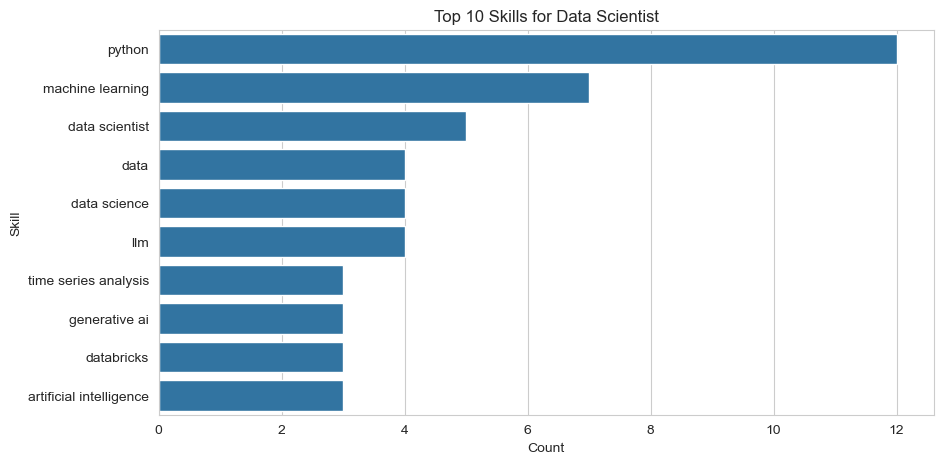

In [57]:
#comparing skill demand visually for one role
role = "Data Scientist"

top_role_skills = role_skill_df[role_skill_df["search_role"] == role]["skill"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_role_skills.values, y=top_role_skills.index)
plt.title(f"Top 10 Skills for {role}")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()

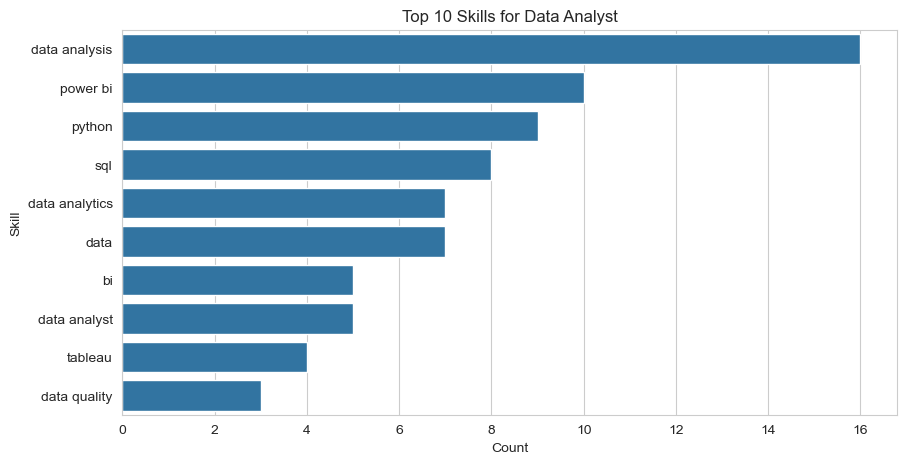

In [58]:
role = "Data Analyst"

top_role_skills = role_skill_df[role_skill_df["search_role"] == role]["skill"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_role_skills.values, y=top_role_skills.index)
plt.title(f"Top 10 Skills for {role}")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()

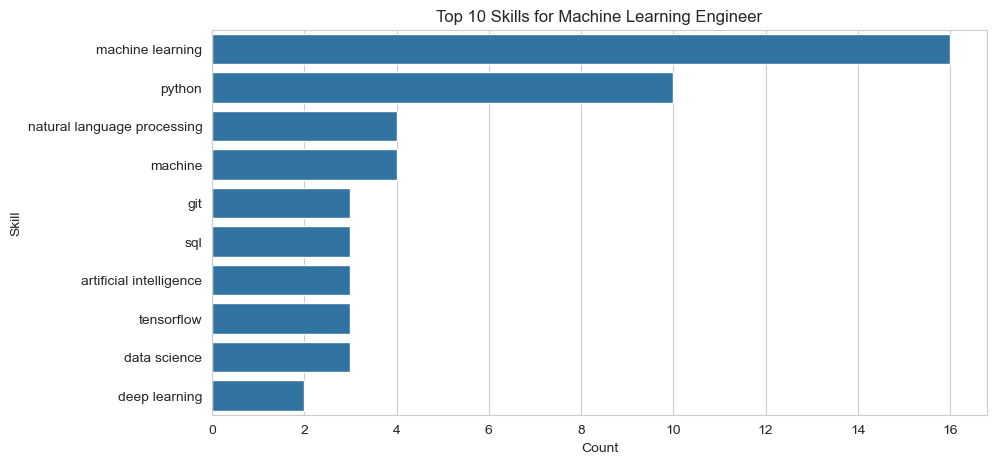

In [59]:
role = "Machine Learning Engineer"

top_role_skills = role_skill_df[role_skill_df["search_role"] == role]["skill"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_role_skills.values, y=top_role_skills.index)
plt.title(f"Top 10 Skills for {role}")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()

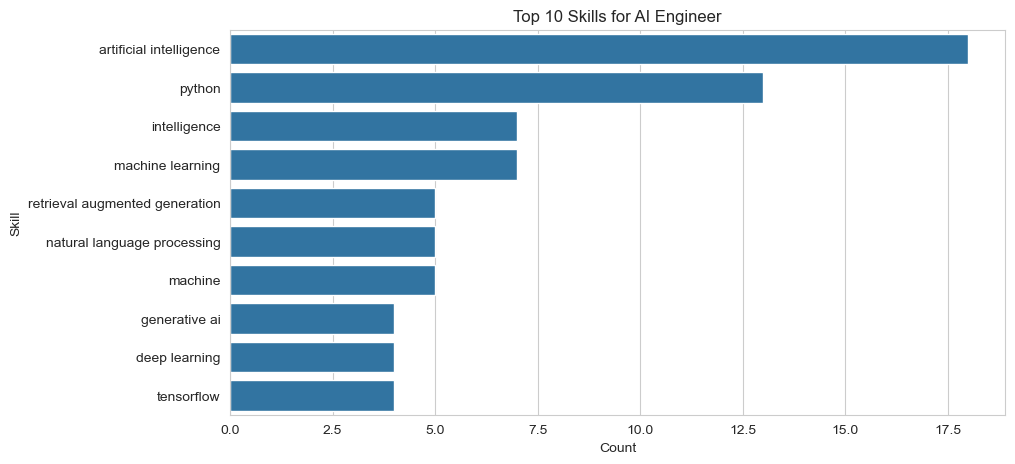

In [60]:
role = "AI Engineer"

top_role_skills = role_skill_df[role_skill_df["search_role"] == role]["skill"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_role_skills.values, y=top_role_skills.index)
plt.title(f"Top 10 Skills for {role}")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.show()

## Scaling dataset

In [61]:
roles = {
    "Data Scientist": "data-scientist-jobs",
    "Data Analyst": "data-analyst-jobs",
    "Machine Learning Engineer": "machine-learning-engineer-jobs",
    "AI Engineer": "artificial-intelligence-engineer-jobs",
    "Data Engineer": "data-engineer-jobs",

    "Frontend Developer": "frontend-developer-jobs",
    "Backend Developer": "backend-developer-jobs",
    "Full Stack Developer": "full-stack-developer-jobs",
    "MERN Stack Developer": "mern-stack-developer-jobs",
    "Java Developer": "java-developer-jobs",
    "Python Developer": "python-developer-jobs",
    "Software Engineer": "software-engineer-jobs",

    "Cyber Security Analyst": "cyber-security-jobs",
    "Security Engineer": "security-engineer-jobs",
    "Ethical Hacker": "ethical-hacker-jobs",
    "SOC Analyst": "soc-analyst-jobs",

    "DevOps Engineer": "devops-engineer-jobs",
    "Cloud Engineer": "cloud-engineer-jobs",
    "Site Reliability Engineer": "site-reliability-engineer-jobs",
    "System Administrator": "system-administrator-jobs",

    "Android Developer": "android-developer-jobs",
    "Flutter Developer": "flutter-developer-jobs",
    "QA Engineer": "qa-engineer-jobs",
    "Test Engineer": "test-engineer-jobs",
    "Product Analyst": "product-analyst-jobs"
}

In [62]:
pages_to_scrape = 5  

In [63]:
all_jobs = []

for role_name, role_slug in roles.items():
    print(f"\nScraping Role: {role_name}")

    for page in range(1, pages_to_scrape + 1):
        url = f"https://www.naukri.com/{role_slug}-{page}"
        
        print(f"  Page {page}: {url}")
        
        driver.get(url)
        time.sleep(4)

        job_cards = driver.find_elements(By.CSS_SELECTOR, "div.cust-job-tuple")
        print(f"   Jobs found: {len(job_cards)}")

        for card in job_cards:
            try:
                # Title
                try:
                    job_title = card.find_element(By.CSS_SELECTOR, "a.title").text
                    job_link = card.find_element(By.CSS_SELECTOR, "a.title").get_attribute("href")
                except:
                    job_title, job_link = None, None

                # Company
                try:
                    company = card.find_element(By.CSS_SELECTOR, "a.comp-name").text
                except:
                    company = None

                # Experience
                try:
                    exp = card.find_element(By.CSS_SELECTOR, "span.expwdth").text
                except:
                    exp = None

                # Location
                try:
                    loc = card.find_element(By.CSS_SELECTOR, "span.locWdth").text
                except:
                    loc = None

                # Skills
                try:
                    skills_elements = card.find_elements(By.CSS_SELECTOR, "ul.tags-gt li")
                    skills = ", ".join([s.text for s in skills_elements if s.text.strip()])
                except:
                    skills = None

                # Posted
                try:
                    posted = card.find_element(By.CSS_SELECTOR, "span.job-post-day").text
                except:
                    posted = None

                all_jobs.append({
                    "search_role": role_name,
                    "job_title": job_title,
                    "company_name": company,
                    "experience": exp,
                    "location": loc,
                    "skills": skills,
                    "posted_date": posted,
                    "job_link": job_link
                })

            except Exception as e:
                print("Error:", e)


Scraping Role: Data Scientist
  Page 1: https://www.naukri.com/data-scientist-jobs-1
   Jobs found: 25
  Page 2: https://www.naukri.com/data-scientist-jobs-2
   Jobs found: 20
  Page 3: https://www.naukri.com/data-scientist-jobs-3
   Jobs found: 20
  Page 4: https://www.naukri.com/data-scientist-jobs-4
   Jobs found: 20
  Page 5: https://www.naukri.com/data-scientist-jobs-5
   Jobs found: 20

Scraping Role: Data Analyst
  Page 1: https://www.naukri.com/data-analyst-jobs-1
   Jobs found: 20
  Page 2: https://www.naukri.com/data-analyst-jobs-2
   Jobs found: 20
  Page 3: https://www.naukri.com/data-analyst-jobs-3
   Jobs found: 20
  Page 4: https://www.naukri.com/data-analyst-jobs-4
   Jobs found: 20
  Page 5: https://www.naukri.com/data-analyst-jobs-5
   Jobs found: 20

Scraping Role: Machine Learning Engineer
  Page 1: https://www.naukri.com/machine-learning-engineer-jobs-1
   Jobs found: 20
  Page 2: https://www.naukri.com/machine-learning-engineer-jobs-2
   Jobs found: 20
  Page 3: 

In [64]:
df_all = pd.DataFrame(all_jobs)

print("Total scraped rows:", len(df_all))
df_all.head()

Total scraped rows: 2548


,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources",1 day ago,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
1,Data Scientist,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics",6 days ago,https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991
2,Data Scientist,Data Science Lead,None,None,None,,None,None
3,Data Scientist,Head Artificial Intelligence,None,None,None,,None,None
4,Data Scientist,,None,None,None,,None,None


In [66]:
df_all_jobs_clean.to_csv("naukri_jobs_dataset.csv", index=False)

print("Final dataset saved!")

Final dataset saved!


In [68]:
print("Raw scraped rows:", len(df_all))
print("Cleaned rows:", len(df_all_jobs_clean))

Raw scraped rows: 2548
Cleaned rows: 79


In [69]:
df_check = pd.read_csv("naukri_jobs_dataset.csv")
print("Rows in saved CSV:", len(df_check))
df_check.head()

Rows in saved CSV: 79


,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources",1 day ago,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
1,Data Scientist,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics",6 days ago,https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991
2,Data Scientist,Data Scientist,Infosys,5-10 Yrs,"Hybrid - Hyderabad, Chennai, Bengaluru","NLP, Generative AI, Computer Vision, Computer, Artificial Intelligence, Data, Vision, Natural language processing",2 days ago,https://www.naukri.com/job-listings-data-scientist-infosys-hyderabad-chennai-bengaluru-5-to-10-years-300326019242
3,Data Scientist,Data Scientist,Mercedes Benz,3-6 Yrs,Bengaluru,"data scientist, kubernetes, python, scala, data mining, aks, databricks, machine learning",1 day ago,https://www.naukri.com/job-listings-data-scientist-mercedes-benz-research-and-development-india-pvt-ltd-bengaluru-3-to-6-years-020426925684
4,Data Scientist,Data Scientist,EY,7-10 Yrs,"Hybrid - Kochi, Bengaluru, Thiruvananthapuram","python, Machine Learning, sql, Statistical Modeling, data scientist, Tensorflow, Azure, Generative Ai",1 week ago,https://www.naukri.com/job-listings-data-scientist-ey-kochi-bengaluru-thiruvananthapuram-7-to-10-years-041225020462


In [70]:
print("Total raw rows:", len(df_all))

print("\nMissing values:")
print(df_all.isnull().sum())

print("\nSample rows with missing company:")
print(df_all[df_all["company_name"].isnull()].head(10))

print("\nSample rows with missing location:")
print(df_all[df_all["location"].isnull()].head(10))

Total raw rows: 2548

Missing values:
search_role       0
job_title         0
company_name     52
experience      101
location         75
skills            0
posted_date      52
job_link         52
dtype: int64

Sample rows with missing company:
            search_role                     job_title company_name experience  \
2        Data Scientist             Data Science Lead         None       None   
3        Data Scientist  Head Artificial Intelligence         None       None   
4        Data Scientist                                       None       None   
5        Data Scientist                                       None       None   
6        Data Scientist                                       None       None   
507  Frontend Developer           Fullstack Developer         None       None   
508  Frontend Developer            React Js Developer         None       None   
509  Frontend Developer                                       None       None   
510  Frontend Developer  

In [71]:
df_better = df_all.copy()

# Fill missing text fields with empty string for safer filtering
for col in ["search_role", "job_title", "company_name", "experience", "location", "skills", "posted_date", "job_link"]:
    df_better[col] = df_better[col].fillna("").astype(str).str.strip()

# Remove rows where BOTH title and link are missing
df_better = df_better[~((df_better["job_title"] == "") & (df_better["job_link"] == ""))]

# Remove rows where title is too short
df_better = df_better[df_better["job_title"].str.len() > 3]

# Remove obvious junk rows
junk_titles = ["", "save", "view", "apply"]
df_better = df_better[~df_better["job_title"].str.lower().isin(junk_titles)]

# Remove duplicates based on job link (best unique identifier)
df_better = df_better.drop_duplicates(subset=["job_link"])

# Reset index
df_better = df_better.reset_index(drop=True)

print("Rows after better cleaning:", len(df_better))
df_better.head(10)

Rows after better cleaning: 2333


,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources",1 day ago,https://www.naukri.com/job-listings-data-scientist-abb-india-limited-bengaluru-2-to-7-years-010426915284
1,Data Scientist,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science, Supply chain operations, data visualization, Customer engagement, cisco, Analytics",6 days ago,https://www.naukri.com/job-listings-data-scientist-cisco-bengaluru-7-to-10-years-270326504991
2,Data Scientist,Data Science Lead,,,,,,
3,Data Scientist,Data Scientist,Infosys,5-10 Yrs,"Hybrid - Hyderabad, Chennai, Bengaluru","NLP, Generative AI, Computer Vision, Computer, Artificial Intelligence, Data, Vision, Natural language processing",3 days ago,https://www.naukri.com/job-listings-data-scientist-infosys-hyderabad-chennai-bengaluru-5-to-10-years-300326019242
4,Data Scientist,Walk-in || Data Scientist,Tata Consultancy Services,,,"Machine Learning, Python, Artificial Intelligence, llm, Ml, Machine, Intelligence, Data",6 days ago,https://www.naukri.com/job-listings-data-scientist-tata-consultancy-services-bhubaneswar-4-to-9-years-280326006567
5,Data Scientist,Data Scientist,Mercedes Benz,3-6 Yrs,Bengaluru,"data scientist, kubernetes, python, scala, data mining, aks, databricks, machine learning",1 day ago,https://www.naukri.com/job-listings-data-scientist-mercedes-benz-research-and-development-india-pvt-ltd-bengaluru-3-to-6-years-020426925684
6,Data Scientist,Data Scientist,EY,7-10 Yrs,"Hybrid - Kochi, Bengaluru, Thiruvananthapuram","python, Machine Learning, sql, Statistical Modeling, data scientist, Tensorflow, Azure, Generative Ai",1 week ago,https://www.naukri.com/job-listings-data-scientist-ey-kochi-bengaluru-thiruvananthapuram-7-to-10-years-041225020462
7,Data Scientist,Data Scientist,Genpact,5-10 Yrs,"Hybrid - Hyderabad, Gurugram, Bengaluru","Artificial Intelligence, Machine Learning, Python, Intelligence, Data, Machine",1 day ago,https://www.naukri.com/job-listings-data-scientist-genpact-hyderabad-gurugram-bengaluru-5-to-10-years-010426025403
8,Data Scientist,Data Scientist,EY,2-6 Yrs,"Delhi / NCR, Mumbai (All Areas)","LLM, Agentic Ai, Langgraph, Function Calling, AWS, Semantic Kernel, Langchain, AI Agents",1 week ago,https://www.naukri.com/job-listings-data-scientist-ey-delhi-ncr-mumbai-all-areas-2-to-6-years-260326000141
9,Data Scientist,Data Scientist,PayU,0-3 Yrs,Gurugram,"Usage, Statistical analysis, Analytical, Focus, Programming, Data mining, Business understanding, Analytics",3 days ago,https://www.naukri.com/job-listings-data-scientist-payu-india-gurugram-0-to-3-years-300326502718


In [72]:
df_better.to_csv("naukri_jobs_dataset.csv", index=False)
print("Corrected dataset saved successfully!")

Corrected dataset saved successfully!


In [74]:
df_final = pd.read_csv("naukri_jobs_dataset.csv")
print("Final saved rows:", len(df_final))

Final saved rows: 2333


## for entire dataset

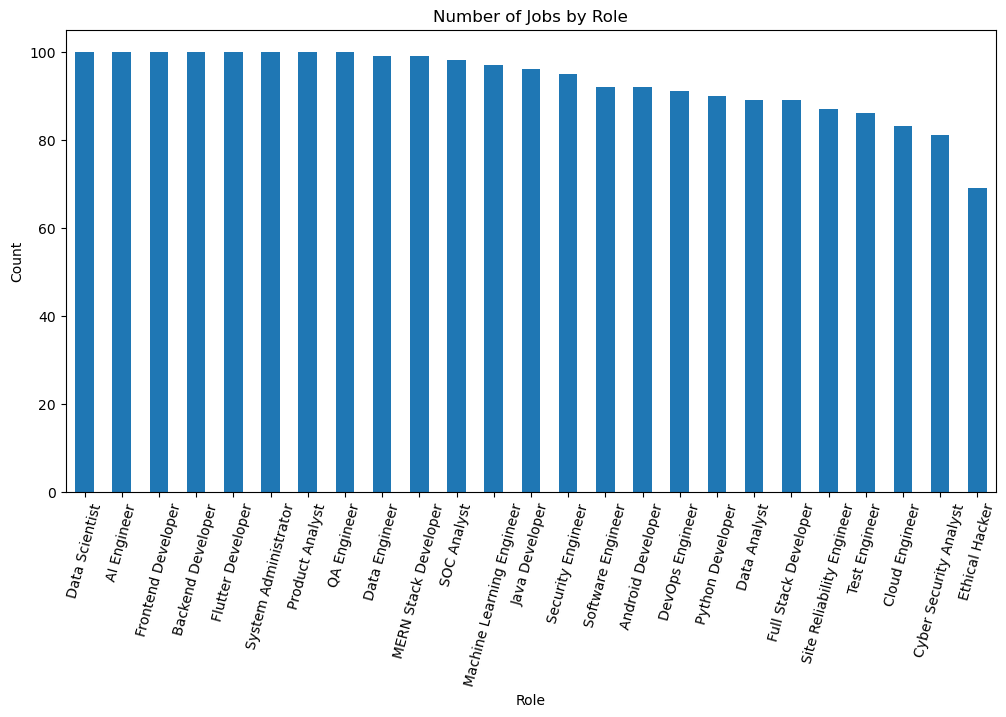

In [6]:
plt.figure(figsize=(12,6))
df["search_role"].value_counts().plot(kind="bar")
plt.title("Number of Jobs by Role")
plt.xlabel("Role")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

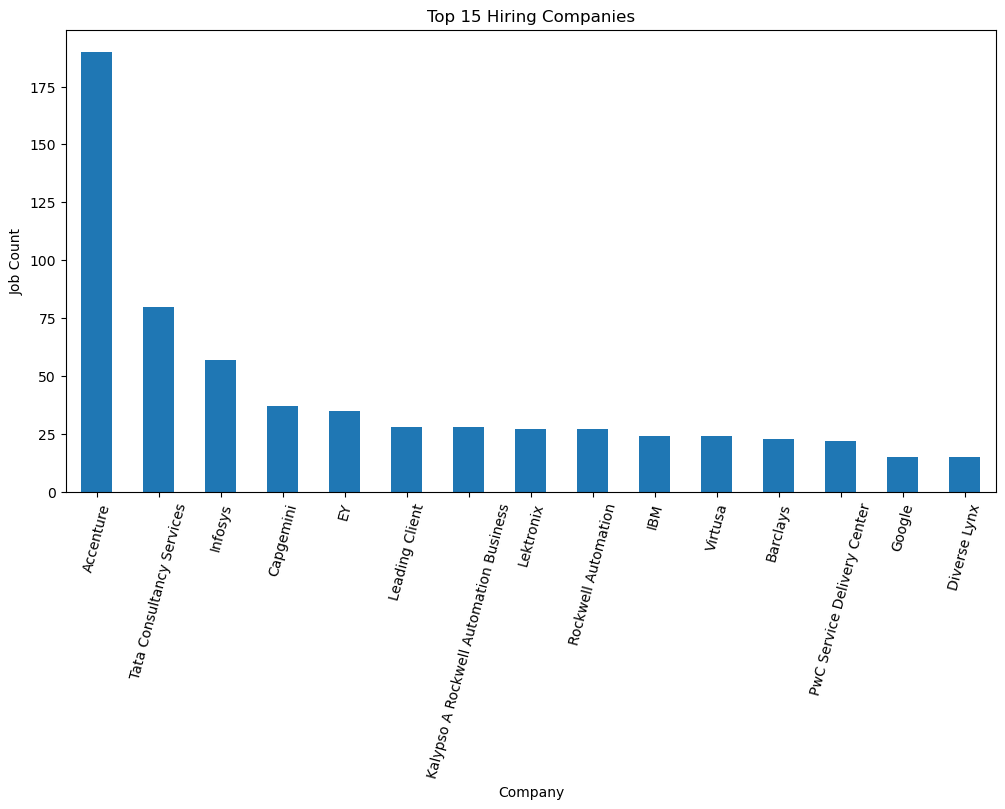

In [8]:
plt.figure(figsize=(12,6))
df["company_name"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Job Count")
plt.xticks(rotation=75)
plt.show()

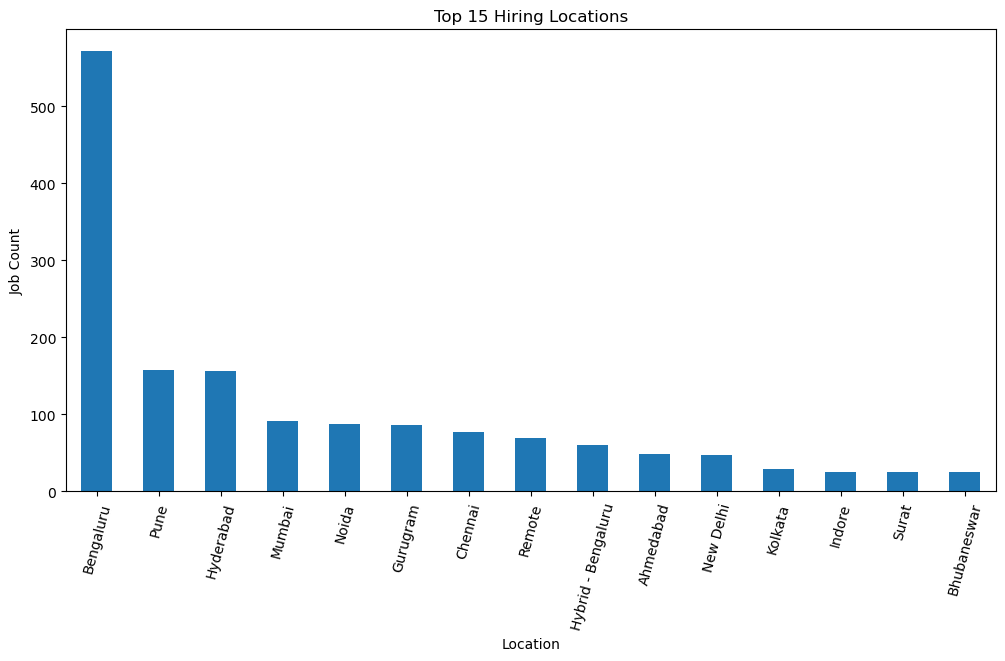

In [9]:
plt.figure(figsize=(12,6))
df["location"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Hiring Locations")
plt.xlabel("Location")
plt.ylabel("Job Count")
plt.xticks(rotation=75)
plt.show()

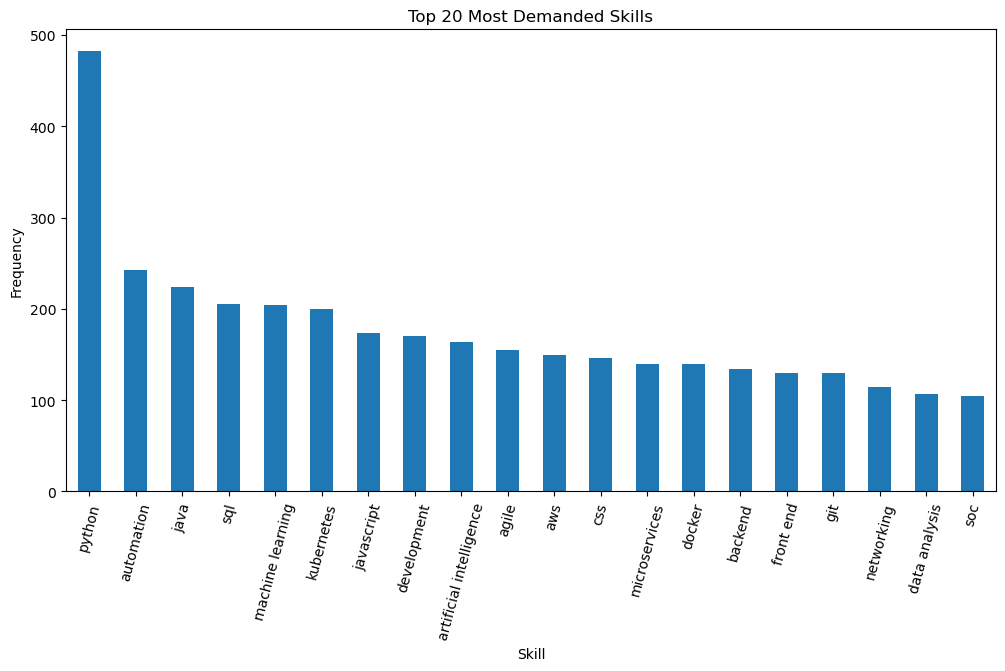

In [10]:
all_skills = df["skills"].dropna().str.lower().str.split(", ")
all_skills_flat = [skill for sublist in all_skills for skill in sublist if skill]

skills_series = pd.Series(all_skills_flat)
top_skills = skills_series.value_counts().head(20)

plt.figure(figsize=(12,6))
top_skills.plot(kind="bar")
plt.title("Top 20 Most Demanded Skills")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.show()

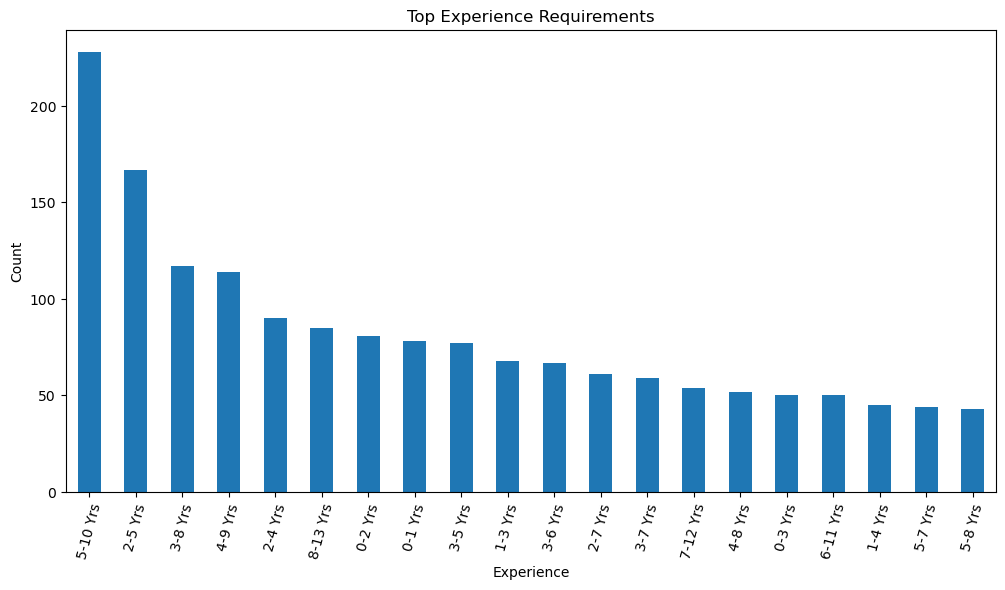

In [11]:
plt.figure(figsize=(12,6))
df["experience"].value_counts().head(20).plot(kind="bar")
plt.title("Top Experience Requirements")
plt.xlabel("Experience")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

In [15]:
fresher_keywords = ["0-1", "0-2", "0-3", "1-3", "fresher", "freshers"]

df["experience"] = df["experience"].fillna("").astype(str).str.lower()

df_freshers = df[df["experience"].apply(
    lambda x: any(keyword in x for keyword in fresher_keywords)
)].copy()

print("Total fresher-friendly jobs:", len(df_freshers))
df_freshers.head()

Total fresher-friendly jobs: 327


,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
9,Data Scientist,Data Scientist,PayU,0-3 yrs,Gurugram,"Usage, Statistical analysis, Analytical, Focus...",3 days ago,https://www.naukri.com/job-listings-data-scien...
14,Data Scientist,Data Scientist,Paytm,1-3 yrs,Gurugram,"data scientist, algorithms, python, scala, dat...",2 days ago,https://www.naukri.com/job-listings-data-scien...
22,Data Scientist,Data Scientist,Siemens,10-15 yrs,Bengaluru,"data scientist, time series analysis, snowflak...",6 days ago,https://www.naukri.com/job-listings-data-scien...
39,Data Scientist,Data Scientist - Service Parts Supply Chain,Philips,10-15 yrs,Bengaluru,"Supply chain, Supply chain management, ERP, Pe...",1 day ago,https://www.naukri.com/job-listings-data-scien...
45,Data Scientist,Data Scientist,Narayana Health (NH),1-3 yrs,Hybrid - Bengaluru,"Tensorflow, Machine Learning, Python, Artifici...",1 day ago,https://www.naukri.com/job-listings-data-scien...


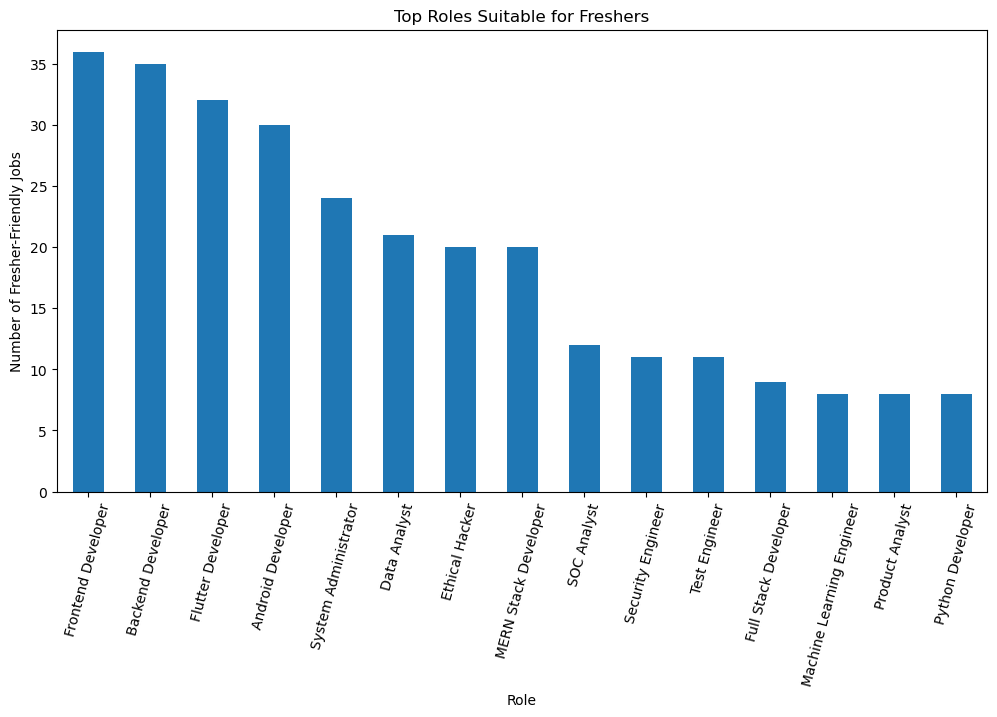

In [17]:
plt.figure(figsize=(12,6))
df_freshers["search_role"].value_counts().head(15).plot(kind="bar")
plt.title("Top Roles Suitable for Freshers")
plt.xlabel("Role")
plt.ylabel("Number of Fresher-Friendly Jobs")
plt.xticks(rotation=75)
plt.show()

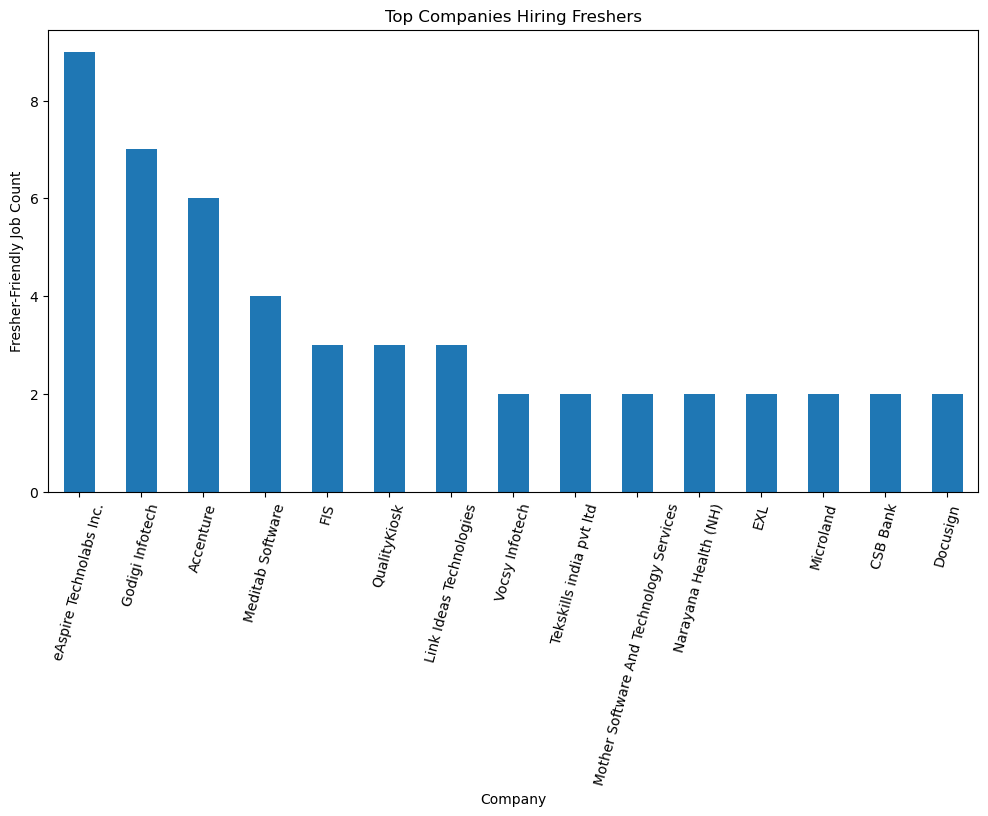

In [18]:
plt.figure(figsize=(12,6))
df_freshers["company_name"].value_counts().head(15).plot(kind="bar")
plt.title("Top Companies Hiring Freshers")
plt.xlabel("Company")
plt.ylabel("Fresher-Friendly Job Count")
plt.xticks(rotation=75)
plt.show()

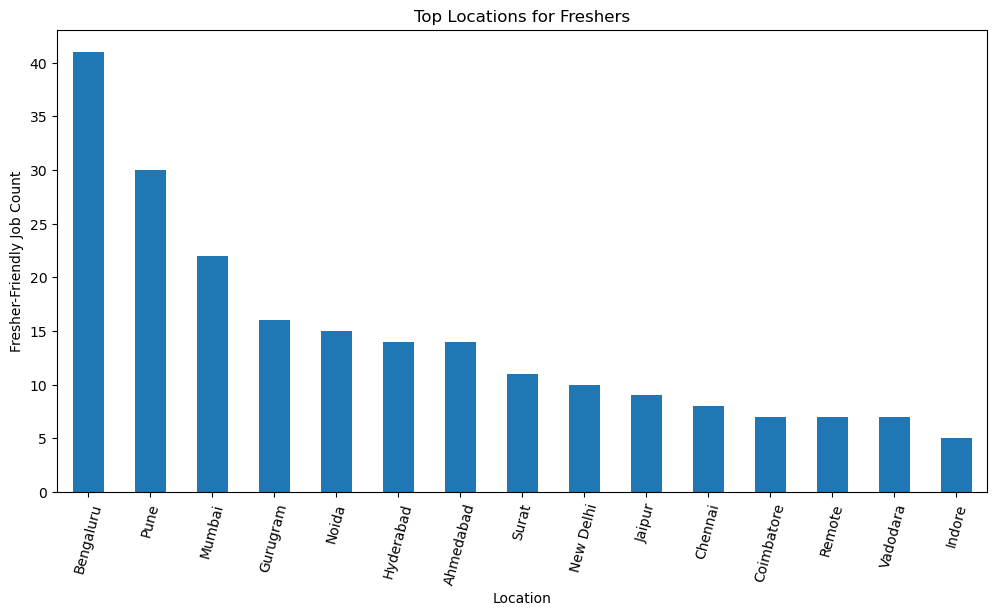

In [19]:
plt.figure(figsize=(12,6))
df_freshers["location"].value_counts().head(15).plot(kind="bar")
plt.title("Top Locations for Freshers")
plt.xlabel("Location")
plt.ylabel("Fresher-Friendly Job Count")
plt.xticks(rotation=75)
plt.show()

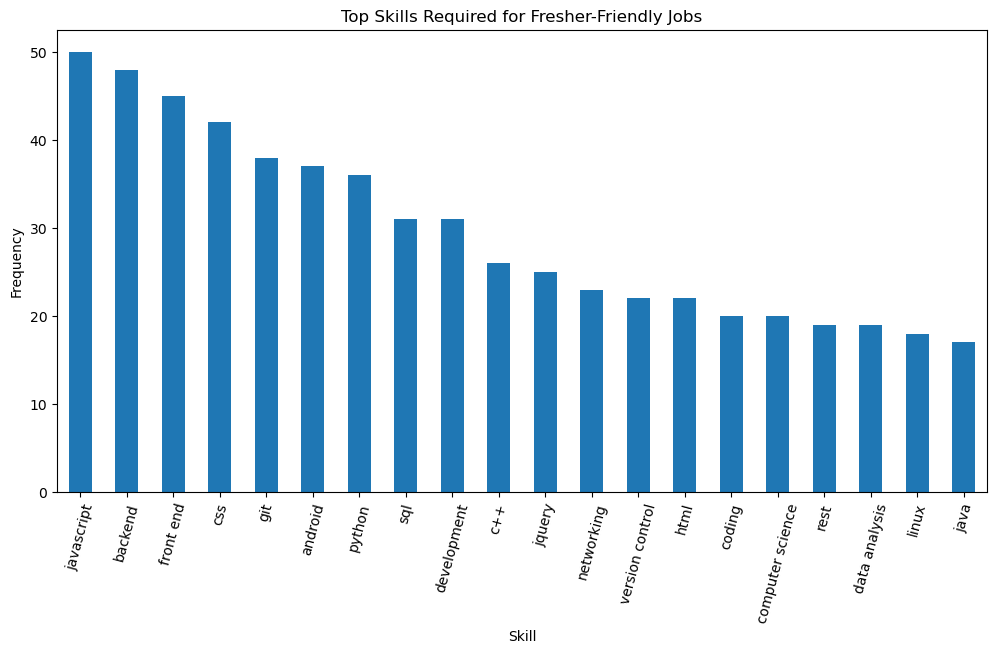

In [20]:
all_fresher_skills = df_freshers["skills"].dropna().str.lower().str.split(", ")
all_fresher_skills_flat = [skill for sublist in all_fresher_skills for skill in sublist if skill]

fresher_skills_series = pd.Series(all_fresher_skills_flat)
top_fresher_skills = fresher_skills_series.value_counts().head(20)

plt.figure(figsize=(12,6))
top_fresher_skills.plot(kind="bar")
plt.title("Top Skills Required for Fresher-Friendly Jobs")
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.xticks(rotation=75)
plt.show()

In [21]:
df_freshers.to_csv("fresher_jobs_dataset.csv", index=False)
print("Fresher jobs dataset saved!")

Fresher jobs dataset saved!


In [22]:
skills_freq = skills_series.value_counts().reset_index()
skills_freq.columns = ["skill", "count"]

skills_freq.to_csv("top_skills_frequency.csv", index=False)
print("Top skills file saved!")
skills_freq.head(20)

Top skills file saved!


,skill,count
0,python,482
1,automation,243
2,java,224
3,sql,205
4,machine learning,204
5,kubernetes,200
6,javascript,174
7,development,170
8,artificial intelligence,164
9,agile,155


In [23]:
df["skills"] = df["skills"].fillna("").str.lower().str.strip()
df["skills_list"] = df["skills"].apply(lambda x: [skill.strip() for skill in x.split(",") if skill.strip() != ""])

role_skill_data = []

for _, row in df.iterrows():
    for skill in row["skills_list"]:
        role_skill_data.append({
            "search_role": row["search_role"],
            "skill": skill
        })

role_skill_df = pd.DataFrame(role_skill_data)

print("Role-skill rows:", len(role_skill_df))
role_skill_df.head()

Role-skill rows: 18072


,search_role,skill
0,Data Scientist,data scientist
1,Data Scientist,time series analysis
2,Data Scientist,storytelling
3,Data Scientist,python
4,Data Scientist,ai


In [24]:
role_skill_df.to_csv("role_wise_skills.csv", index=False)
print("Role-wise skills file saved!")

Role-wise skills file saved!


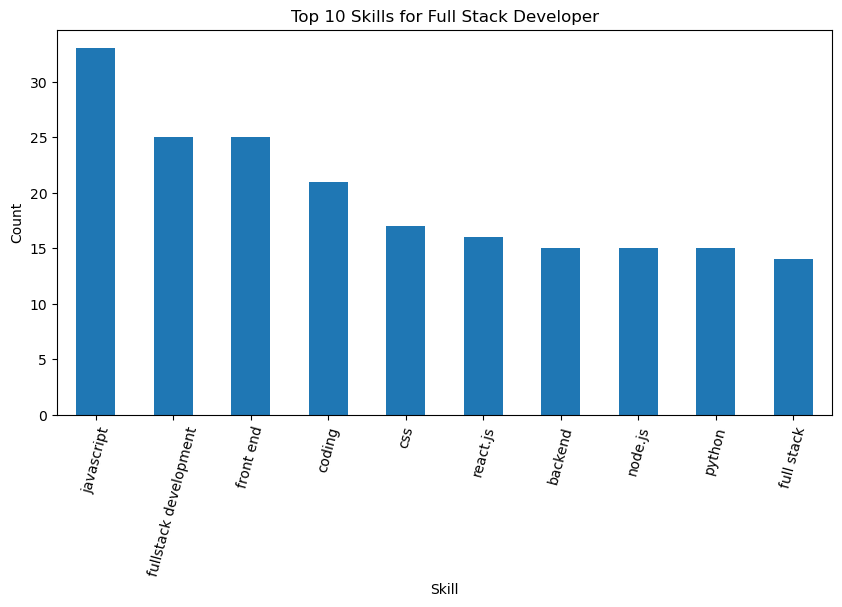

In [26]:
role = "Full Stack Developer"

top_role_skills = role_skill_df[role_skill_df["search_role"] == role]["skill"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_role_skills.plot(kind="bar")
plt.title(f"Top 10 Skills for {role}")
plt.xlabel("Skill")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

## preparing model dataset

In [28]:
import pandas as pd

df_model = pd.read_csv("naukri_jobs_dataset.csv")

print("Loaded rows:", len(df_model))
df_model.head()

Loaded rows: 2333


,search_role,job_title,company_name,experience,location,skills,posted_date,job_link
0,Data Scientist,Data Scientist,ABB,2-7 Yrs,Bengaluru,"data scientist, time series analysis, storytel...",1 day ago,https://www.naukri.com/job-listings-data-scien...
1,Data Scientist,Data Scientist,Cisco,7-10 Yrs,Bengaluru,"Computer science, Data analysis, data science,...",6 days ago,https://www.naukri.com/job-listings-data-scien...
2,Data Scientist,Data Science Lead,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Scientist,Data Scientist,Infosys,5-10 Yrs,"Hybrid - Hyderabad, Chennai, Bengaluru","NLP, Generative AI, Computer Vision, Computer,...",3 days ago,https://www.naukri.com/job-listings-data-scien...
4,Data Scientist,Walk-in || Data Scientist,Tata Consultancy Services,NaN,NaN,"Machine Learning, Python, Artificial Intellige...",6 days ago,https://www.naukri.com/job-listings-data-scien...


In [29]:
df_model = df_model[["skills", "search_role"]].copy()

print("Shape after selecting columns:", df_model.shape)
df_model.head()

Shape after selecting columns: (2333, 2)


,skills,search_role
0,"data scientist, time series analysis, storytel...",Data Scientist
1,"Computer science, Data analysis, data science,...",Data Scientist
2,NaN,Data Scientist
3,"NLP, Generative AI, Computer Vision, Computer,...",Data Scientist
4,"Machine Learning, Python, Artificial Intellige...",Data Scientist


In [30]:
df_model["skills"] = df_model["skills"].fillna("").astype(str).str.lower().str.strip()
df_model["search_role"] = df_model["search_role"].fillna("").astype(str).str.strip()

# Remove empty rows
df_model = df_model[(df_model["skills"] != "") & (df_model["search_role"] != "")]

# Remove duplicate rows
df_model = df_model.drop_duplicates()

# Reset index
df_model = df_model.reset_index(drop=True)

print("Rows after cleaning model data:", len(df_model))
df_model.head()

Rows after cleaning model data: 1958


,skills,search_role
0,"data scientist, time series analysis, storytel...",Data Scientist
1,"computer science, data analysis, data science,...",Data Scientist
2,"nlp, generative ai, computer vision, computer,...",Data Scientist
3,"machine learning, python, artificial intellige...",Data Scientist
4,"data scientist, kubernetes, python, scala, dat...",Data Scientist


In [31]:
print(df_model["search_role"].value_counts())

search_role
AI Engineer                  100
Machine Learning Engineer     95
Security Engineer             92
System Administrator          92
SOC Analyst                   90
Java Developer                90
Backend Developer             89
Data Scientist                87
Android Developer             86
DevOps Engineer               85
Site Reliability Engineer     84
Data Analyst                  83
Full Stack Developer          81
MERN Stack Developer          80
QA Engineer                   80
Test Engineer                 79
Flutter Developer             78
Cyber Security Analyst        78
Python Developer              75
Frontend Developer            73
Cloud Engineer                67
Data Engineer                 64
Ethical Hacker                54
Product Analyst               42
Software Engineer             34
Name: count, dtype: int64


In [32]:
df_model.to_csv("job_role_model_dataset.csv", index=False)
print("Model-ready dataset saved!")

Model-ready dataset saved!


In [33]:
X = df_model["skills"]
y = df_model["search_role"]

print("Sample input (skills):")
print(X.iloc[0])

print("\nSample target (role):")
print(y.iloc[0])

Sample input (skills):
data scientist, time series analysis, storytelling, python, ai, power bi, business analysis, human resources

Sample target (role):
Data Scientist


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1566
Testing rows: 392


In [35]:
#TF-IDF VECTORIZER
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (1566, 3000)
X_test_tfidf shape: (392, 3000)


In [36]:
feature_names = vectorizer.get_feature_names_out()

print("Total learned features:", len(feature_names))
print("\nSample features:")
print(feature_names[:50])

Total learned features: 3000

Sample features:
['0365' '0365 gpo' '0365 windows' '27001' '27001 application'
 '27001 cybersecurity' '27001 database' '27001 lead' '27001 legal'
 '27001 network' '27001 nist' '27001 pci' '27001 schema' '27001 security'
 '27001 siem' '27001 threat' '365' '5g' 'ab' 'ab testing' 'access'
 'access management' 'accessories' 'account' 'account management'
 'accounting' 'acquisition' 'acrobat' 'active' 'active directory'
 'activemq' 'activities' 'adaptability' 'adaptability analytical'
 'administration' 'administration active' 'administration administration'
 'administration agile' 'administration automation' 'administration azure'
 'administration backend' 'administration cisco' 'administration data'
 'administration firewall' 'administration hardware'
 'administration information' 'administration kubernetes'
 'administration linux' 'administration network'
 'administration networking']


In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [39]:
y_pred = model.predict(X_test_tfidf)

print("Sample predictions:")
print(y_pred[:10])

Sample predictions:
['Cloud Engineer' 'AI Engineer' 'Data Analyst' 'System Administrator'
 'AI Engineer' 'Java Developer' 'Frontend Developer' 'QA Engineer'
 'Backend Developer' 'Data Scientist']


In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 69.64 %


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                           precision    recall  f1-score   support

              AI Engineer       0.73      0.80      0.76        20
        Android Developer       0.94      0.88      0.91        17
        Backend Developer       0.60      0.67      0.63        18
           Cloud Engineer       0.67      0.62      0.64        13
   Cyber Security Analyst       0.50      0.56      0.53        16
             Data Analyst       0.72      0.76      0.74        17
            Data Engineer       0.80      0.92      0.86        13
           Data Scientist       0.58      0.41      0.48        17
          DevOps Engineer       0.70      0.82      0.76        17
           Ethical Hacker       1.00      0.09      0.17        11
        Flutter Developer       0.94      0.94      0.94        16
       Frontend Developer       0.74      0.93      0.82        15
     Full Stack Developer       0.54      0.44      0.48        16
           Java Developer       0.79      0.83      0.81     

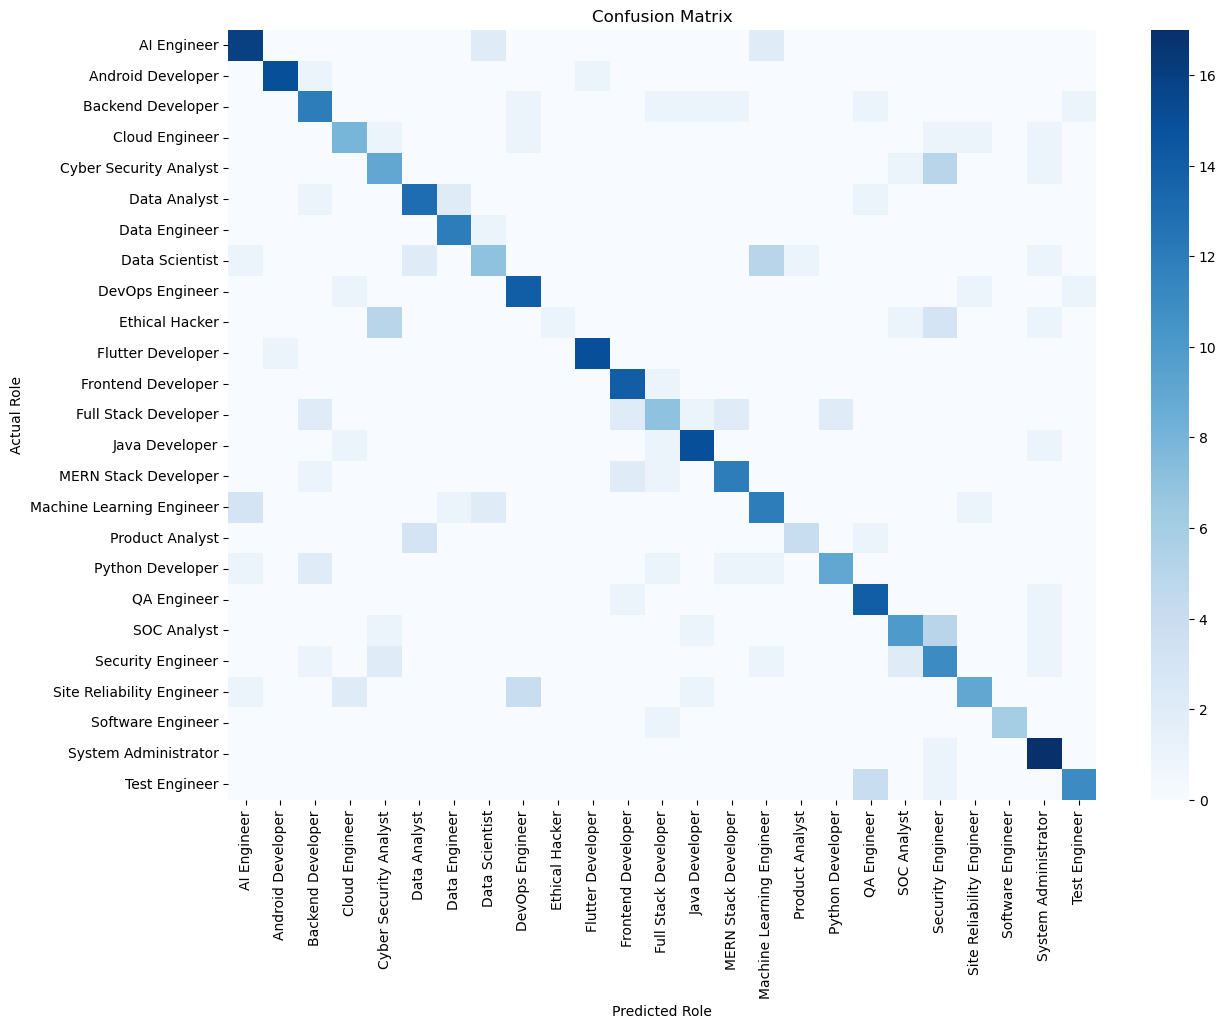

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Role")
plt.ylabel("Actual Role")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [43]:
def predict_role(skills_input):
    skills_input = skills_input.lower().strip()
    skills_vector = vectorizer.transform([skills_input])
    prediction = model.predict(skills_vector)[0]
    return prediction

In [44]:
sample_1 = "python, sql, machine learning, tableau"
sample_2 = "react, node.js, mongodb, express"
sample_3 = "aws, docker, kubernetes, linux"
sample_4 = "penetration testing, siem, soc, cyber security"
sample_5 = "excel, power bi, sql, dashboard"

print("Prediction 1:", predict_role(sample_1))
print("Prediction 2:", predict_role(sample_2))
print("Prediction 3:", predict_role(sample_3))
print("Prediction 4:", predict_role(sample_4))
print("Prediction 5:", predict_role(sample_5))

Prediction 1: Machine Learning Engineer
Prediction 2: MERN Stack Developer
Prediction 3: Cloud Engineer
Prediction 4: SOC Analyst
Prediction 5: Data Analyst


In [45]:
def predict_top_roles(skills_input, top_n=3):
    skills_input = skills_input.lower().strip()
    skills_vector = vectorizer.transform([skills_input])

    probs = model.predict_proba(skills_vector)[0]
    top_indices = np.argsort(probs)[::-1][:top_n]

    top_roles = [(model.classes_[i], round(probs[i] * 100, 2)) for i in top_indices]
    return top_roles

In [46]:
sample = "python, sql, machine learning, tableau"

top_roles = predict_top_roles(sample)

print("Input Skills:", sample)
print("\nTop Recommended Roles:")
for role, score in top_roles:
    print(f"{role} --> {score}%")

Input Skills: python, sql, machine learning, tableau

Top Recommended Roles:
Machine Learning Engineer --> 54.7%
Data Scientist --> 10.76%
Python Developer --> 6.77%


In [47]:
role_skill_df = pd.read_csv("role_wise_skills.csv")

print("Rows in role_skill_df:", len(role_skill_df))
role_skill_df.head()

Rows in role_skill_df: 18072


,search_role,skill
0,Data Scientist,data scientist
1,Data Scientist,time series analysis
2,Data Scientist,storytelling
3,Data Scientist,python
4,Data Scientist,ai


In [49]:
#create top skills for per directory
top_skills_per_role = {}

for role in role_skill_df["search_role"].unique():
    top_skills = (
        role_skill_df[role_skill_df["search_role"] == role]["skill"]
        .value_counts()
        .head(5)
        .index
        .tolist()
    )
    top_skills_per_role[role] = top_skills

print("Sample roles with top skills:")
for role in list(top_skills_per_role.keys())[:5]:
    print(f"\n{role}:")
    print(top_skills_per_role[role])

Sample roles with top skills:

Data Scientist:
['machine learning', 'python', 'data science', 'artificial intelligence', 'data scientist']

Data Analyst:
['data analysis', 'data analytics', 'power bi', 'sql', 'data analyst']

Machine Learning Engineer:
['machine learning', 'python', 'artificial intelligence', 'tensorflow', 'machine']

AI Engineer:
['artificial intelligence', 'python', 'intelligence', 'machine learning', 'natural language processing']

Data Engineer:
['python', 'hive', 'pyspark', 'data modeling', 'sql']


In [51]:
def recommend_missing_skills(user_skills_input, predicted_role, top_n=10):
    user_skills = [skill.strip().lower() for skill in user_skills_input.split(",") if skill.strip()]
    
    role_skills = top_skills_per_role.get(predicted_role, [])
    
    missing_skills = [skill for skill in role_skills if skill.lower() not in user_skills]
    
    return missing_skills[:top_n]

In [52]:
user_input = "python, sql, tableau"

predicted_role = predict_role(user_input)
missing_skills = recommend_missing_skills(user_input, predicted_role)

print("User Skills:", user_input)
print("Predicted Role:", predicted_role)
print("\nRecommended Skills to Learn:")

for skill in missing_skills:
    print("-", skill)

User Skills: python, sql, tableau
Predicted Role: Python Developer

Recommended Skills to Learn:
- python development
- development
- django
- aws
- git
- mysql
- postgresql
- gcp
- version control
- flask


In [53]:
def career_guidance_system(user_skills_input):
    print("User Skills:", user_skills_input)
    
    # Top role predictions
    top_roles = predict_top_roles(user_skills_input, top_n=3)
    
    print("\nTop Recommended Roles:")
    for role, score in top_roles:
        print(f"- {role} ({score}%)")
    
    # Best role
    best_role = top_roles[0][0]
    
    # Missing skills
    missing_skills = recommend_missing_skills(user_skills_input, best_role)
    
    print(f"\nSuggested Skills to Improve for {best_role}:")
    for skill in missing_skills:
        print(f"- {skill}")

In [54]:
career_guidance_system("python, sql, tableau")

User Skills: python, sql, tableau

Top Recommended Roles:
- Python Developer (16.72%)
- Data Engineer (7.89%)
- Machine Learning Engineer (6.69%)

Suggested Skills to Improve for Python Developer:
- python development
- development
- django
- aws
- git
- mysql
- postgresql
- gcp
- version control
- flask


In [56]:
career_guidance_system("react, node.js, mongodb")

User Skills: react, node.js, mongodb

Top Recommended Roles:
- MERN Stack Developer (42.94%)
- Full Stack Developer (16.32%)
- Backend Developer (5.46%)

Suggested Skills to Improve for MERN Stack Developer:
- mern stack
- mern
- javascript
- css
- redux
- react.js
- mean stack
- bootstrap
- ajax
- git


In [57]:
career_guidance_system("aws, docker, linux")

User Skills: aws, docker, linux

Top Recommended Roles:
- Cloud Engineer (22.54%)
- Site Reliability Engineer (9.32%)
- System Administrator (8.95%)

Suggested Skills to Improve for Cloud Engineer:
- cloud
- kubernetes
- python
- microsoft azure
- gcp
- continuous integration
- networking
- ansible
- terraform
- container


In [58]:
import pickle

# Save model
with open("career_role_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [60]:
with open("career_role_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

with open("tfidf_vectorizer.pkl", "rb") as f:
    loaded_vectorizer = pickle.load(f)

sample = "python, sql, tableau"
sample_vector = loaded_vectorizer.transform([sample])

prediction = loaded_model.predict(sample_vector)[0]

print("Loaded model prediction:", prediction)

Loaded model prediction: Python Developer
